# Activity 6.22 - 6.25 Geocoding

In this notebook, you will learn how to geocode different sorts of location data by making requests to several online APIs (*Application Programming Interface*) for latitude and longitude co-ordinates associated with those locations.

The aim of the notebook is *not* to teach you formal approaches for working with APIs or the data that is returned from them. Instead, it's something to whet your curiosity. Something to show you how, with a few lines of Python code, you can start to work with live, third-party datasources and online services to perform real-world programming tasks.

If something doesn't work: *DON'T PANIC*. You won't break your computer and you won't break the internet. And you won't fail the module if you just move on!

The location data we will consider includes:

- <a href="#addresses">Activity 6.22 - Geocoding an address using an API</a>
- <a href="#postcodes">Activity 6.23 - Geocoding addresses and postcodes</a>
- <a href="#IPaddresses">Activity 6.24 - Geocoding an IP address</a>
- <a href="#revgeopostcode">Activity 6.25 - Reverse geocoding a postcode</a>

<a name="addresses"></a>
## Activity 6.22 - Geocoding an address using an API

When Google Maps first appeared in 2005, it existed primarily as a browser based application. Developers soon started to identify the remote Google services that the application relied on and an official API soon followed, along with APIs for other geo-related services such as geocoding.

Since then, a wide range of other providers have opened up publicly accessible geo-related services, including openly licensed mapping services such as OpenStreetmap, as well as geocoding and geolcation services.

Many of these services are accessed programmatically using an API. Some of them, such as the Google APIs, require personal API keys which are associated with registered users and can be used to track, and bill for, usage. Other services, such as Open Street Map, and its associated [Nominatim](https://nominatim.org/release-docs/develop/api/Search/) service, still publish open endpoints that *do not* require an API key.

Do not worry in this activity about the detail of how the call to the API is constructed using Python code or how the response is constructed. The main aim of this activity is simply to demonstrate that small amounts of code *can* be used to generate requests to third party online services, parse the response, and do something simple with it. However, if you do peek into the entrails of the data object that is returned, you may be able to identify recognisable things within it.

In [68]:
# The requests library makes it easy to call URLs using Python
import requests

Specify the address for which we want to find the geocoded location (you could use your own address here):

In [69]:
address = "Open University, Walton Hall, Milton Keynes, MK7 6AA, UK"

Now we can construct a URL to call on the Nomimatim web service using this address as an argument.

Note that we are also requesting that the service provides a response using JSON (Javascript Object Notation) formatted data.

In [70]:
# Construct a request to the Nominatim geolocation service
# using our desired address
# Obtain the response in JSON data format
# # Define headers with a custom User-Agent
headers = {"User-Agent": "OpenUniversity-TM112/1.0"}

r = requests.get(
    "https://nominatim.openstreetmap.org/search",
    headers=headers,
    params={"q": address, "format": "json"},
)

response_data = r.json()
response_data

[{'place_id': 279727848,
  'licence': 'Data © OpenStreetMap contributors, ODbL 1.0. http://osm.org/copyright',
  'osm_type': 'way',
  'osm_id': 44106237,
  'lat': '52.0245378',
  'lon': '-0.7092748',
  'class': 'amenity',
  'type': 'university',
  'place_rank': 30,
  'importance': 6.352254520480686e-05,
  'addresstype': 'amenity',
  'name': 'The Open University',
  'display_name': 'The Open University, Walton Drive, Tower Gate, Walton, Monkston, Milton Keynes, City of Milton Keynes, England, MK7 6AA, United Kingdom',
  'boundingbox': ['52.0207970', '52.0281706', '-0.7155217', '-0.7032044']}]

Try rerunning the previous cell with an address that is familiar to you. Does the API find it?

### Optional Activities

- try to display the location of an address you have geolocated on a map using `folium_magic`. Remember, you can pass in the co-ordinates literally; for example: `%folium_map -m 48.8584,2.2945`. Set the zoom level by adding `-z ZOOM_LEVEL`, eg `-z 17` or `-z 12`.

In [71]:
%load_ext folium_magic

The folium_magic extension is already loaded. To reload it, use:
  %reload_ext folium_magic


In [72]:
# Go for it... :-)

In [73]:
%folium_map -m 52.024924,-0.709727,"Milton Keynes Campus" -z 15

<a name="postcodes"></a>
## Activity 6.23 - Geocoding addresses and postcodes

Postcodes are a widely used form of location data, typically capable of identifying a location to a resolution of a few hundred square metres.

There are several online services that will return geolocation information given a postcode. You have alreay seen how the Google geolocation API can geocode an address, and in many cases it can also geocode a postcode if it can identify it as such; providing a postcode + country name as the address can make this more reliable.

As you are perhaps starting to see from these notebook activities, data is often returned from webservices using the JSON (Javascript Object Notation) data format, although some APIs allow you to specify other formats such as XML.

(One advantage of the JSON response is that it can be immediately consumed by a Javascript script called from inside a webpage.)

JSON and XML both allow data to be represented in a structured, *tree* based hierarchical format. In this notebook, as well exploring a new API published via the *postcodes.io* website, we'll start to look in a little bit more detail at how the JSON response is structured.

### Looking at the data object returned from the `postcodes.io` API

The *postcodes.io* API returns data as hierarchical, tree based JSON object. The tree has the following form:

![Hierarchical structure of postocdes api data, showing results tree with latitude, longitude and codes children, and codes showing admin_district and parish district](images/postodes_io_struct.png)

<!--- http://blockdiag.com/en/blockdiag/demo.html
{

  "result" -> "postcode";
"result" -> "country";
"result" -> "longitude";
"result" -> "latitude";
"dots" [shape = "dots"];
"result" -> "dots" [style = "none"];
"result" -> "codes";
"codes" -> "admin_district";
"dots2" [shape = "dots"];
"codes" -> "dots2" [style = "none"];
"codes" -> "parish";

})

--->

The `result` node is at the top of the tree with children `postcode`, `latitude`, `longitude` and so on. The `codes` child has further children, such as: `admin` and `parish`.

In *python*, data structures of this form can be represented using the `dict` ("dictionary") structure, which you will meet elsewhere in the course.

The *python* `requests` library has a method that parses a correctly formed JSON response as a *python* `dict`, or more generally, as a set of *nested dicts*. In this case, one `dict` structure may be nested inside another to support child, grandchild, great grandchild, and so on, levels of structure.

![Hierarchical structure of postocdes api data, showing results tree with latitude, longitude and codes children, and codes showing admin_district and parish district](images/postodes_io_struct_data.png)

The contents of different levels of the nested `dict` data structure can be accessed by using a form of associative, relative addressing. For example, if the variable `mypostcode` is set to the `dict` shown above, we could access the contents of the main `result` part of the data structure by writing: `mypostcode["result"]`.

To obtain the value of items in deeper nested parts of the data structure, we simply add further levels of relative addressing. To fetch the value of the `postcode`, we need to specify the path to it via the `result` node: `mypostcode["result"]["postcode"]`. To obtain the value of the `parish` in the `code` part of the data structure, we specify the path to it as `mypostcode["result"]["code"]["parish"]`.

Run the following cells to call the `postcodes.io` API with a particular postcode.

See if you can make sense of the result that is returned.

In [74]:
# The requests library makes it easy to call URLs using Python
import requests

In [75]:
postcode = "MK7 6AA"

r = requests.get("https://api.postcodes.io/postcodes/{PC}".format(PC=postcode))
response_data = r.json()
response_data

{'status': 200,
 'result': {'postcode': 'MK7 6AA',
  'quality': 1,
  'eastings': 488625,
  'northings': 237063,
  'country': 'England',
  'nhs_ha': 'South Central',
  'longitude': -0.709727,
  'latitude': 52.024924,
  'european_electoral_region': 'South East',
  'primary_care_trust': 'Milton Keynes',
  'region': 'South East',
  'lsoa': 'Milton Keynes 035D',
  'msoa': 'Milton Keynes 035',
  'incode': '6AA',
  'outcode': 'MK7',
  'parliamentary_constituency': 'Milton Keynes Central',
  'parliamentary_constituency_2024': 'Milton Keynes Central',
  'senedd_constituency': None,
  'senedd_constituency_no': None,
  'admin_district': 'Milton Keynes',
  'parish': 'Walton',
  'admin_county': None,
  'date_of_introduction': '198001',
  'date_of_termination': None,
  'index_of_multiple_deprivation': 20531,
  'admin_ward': 'Monkston',
  'ced': None,
  'ccg': 'NHS Central East',
  'nuts': 'Milton Keynes',
  'pfa': 'Thames Valley',
  'nhs_region': 'East of England',
  'ttwa': 'Milton Keynes',
  'nati

Try rerunning the previous cell using different postcodes - can the service locate your home postcode?

### Parsing the `postcodes.io` JSON data

Once we have retrieved the data from the API, and cast it as a *python* data object, we can look inside it programmatically.

We can also create variables that contain subsets of the response data.

In [76]:
results = response_data["result"]
results

{'postcode': 'MK7 6AA',
 'quality': 1,
 'eastings': 488625,
 'northings': 237063,
 'country': 'England',
 'nhs_ha': 'South Central',
 'longitude': -0.709727,
 'latitude': 52.024924,
 'european_electoral_region': 'South East',
 'primary_care_trust': 'Milton Keynes',
 'region': 'South East',
 'lsoa': 'Milton Keynes 035D',
 'msoa': 'Milton Keynes 035',
 'incode': '6AA',
 'outcode': 'MK7',
 'parliamentary_constituency': 'Milton Keynes Central',
 'parliamentary_constituency_2024': 'Milton Keynes Central',
 'senedd_constituency': None,
 'senedd_constituency_no': None,
 'admin_district': 'Milton Keynes',
 'parish': 'Walton',
 'admin_county': None,
 'date_of_introduction': '198001',
 'date_of_termination': None,
 'index_of_multiple_deprivation': 20531,
 'admin_ward': 'Monkston',
 'ced': None,
 'ccg': 'NHS Central East',
 'nuts': 'Milton Keynes',
 'pfa': 'Thames Valley',
 'nhs_region': 'East of England',
 'ttwa': 'Milton Keynes',
 'national_park': 'England (non-National Park)',
 'bua': 'Milton 

Let's extract the latitude and longitude values. We can reach them in a variety of ways.

In [77]:
# Index into the full response data
lat = response_data["result"]["latitude"]

# Index into the subsetted data
lon = results["longitude"]

# Display the result
print(lat, lon)

52.024924 -0.709727


### Optional Activities

- use `folium magic` to map the location of an address you have provided;
- see if you can create a variable that contains the formatted address of a location object retrieved from the postcods.io API;
- see if you can write a loop that will look up the geolocations of several postcodes, one at a time, appending each response object to a list of responses. To be nice to the API import the *python* `time` library and add the statement `time.sleep(1)` inside the loop to pause its execution for one second during each iteration. 
- use some `folium_magic` to display one or markers for each of your (looped) postcodes. You can use the `-M` switch to add multiple markers from a Python variable; pass in the name of a variable that refers to *without* the $ prefix. For example, if the markers are assigned to the variable `markers` use the magic `%folium_map -M markers`:
  - a single `dict`, such as `markers={'lat':52.0250, 'lng':-0.7084,'popup':'Open University, Walton Hall'}`
  - a single ordered `list`, such as `markers=[52.0250, -0.7084,'Open University, Walton Hall']`
  - a `list` of `dict`s, such as `markers=[{'lat':52.0250, 'lng':-0.7084,'popup':'Open University, Walton Hall'},{'lat':52.0, 'lng':-0.70,'popup':'Open University, Walton Hall'}]`
  - a `list` of ordered `lists`, such as `markers=[[52.0250, -0.7084,'Open University, Walton Hall'], [52., -0.7,'Open University, Walton Hall']]`

In [78]:
import requests

postcode = "MK7 6AA"
url = f"https://api.postcodes.io/postcodes/{postcode}"
response = requests.get(url).json()

if response.get("status") == 200:
    res = response["result"]
    # Construct a formatted address string from the returned location attributes
    formatted_address = (
        f"{res['parish']}, {res['admin_district']}, {res['region']}, {res['postcode']}"
    )
    lat = res["latitude"]
    lon = res["longitude"]

    print("Formatted Address:", formatted_address)
    print(f"Coordinates: ({lat}, {lon})")

# Map the single location using folium_magic string interpolation
get_ipython().run_line_magic(
    "folium_map", f"-m {lat},{lon},'{formatted_address}' -z 15"
)

Formatted Address: Walton, Milton Keynes, South East, MK7 6AA
Coordinates: (52.024924, -0.709727)


In [79]:
import time
import requests

postcodes_to_lookup = ["MK7 6AA", "SW1A 1AA", "EH1 1YT", "CF10 1NS"]
responses = []

for pc in postcodes_to_lookup:
    url = f"https://api.postcodes.io/postcodes/{pc}"
    res = requests.get(url).json()

    if res.get("status") == 200:
        responses.append(res["result"])
        print(f"Successfully retrieved: {pc}")

    # Pause for 1 second between requests
    time.sleep(1)

print(f"\nCollected {len(responses)} location objects.")

Successfully retrieved: MK7 6AA
Successfully retrieved: SW1A 1AA
Successfully retrieved: CF10 1NS

Collected 3 location objects.


In [80]:
# Format the collected responses into a list of dicts required by folium_magic -M
markers = []
for item in responses:
    markers.append(
        {
            "lat": item["latitude"],
            "lng": item["longitude"],
            "popup": f"{item['postcode']} ({item['admin_district']})",
        }
    )

print("Markers variable:", markers)

Markers variable: [{'lat': 52.024924, 'lng': -0.709727, 'popup': 'MK7 6AA (Milton Keynes)'}, {'lat': 51.50101, 'lng': -0.141563, 'popup': 'SW1A 1AA (Westminster)'}, {'lat': 51.478283, 'lng': -3.182652, 'popup': 'CF10 1NS (Cardiff)'}]


In [81]:
%folium_map -M markers -z 6

<a name="IPaddresses"></a>
## Activity 6.24 - Geocoding an IP address

As well as looking up geolocation data for a *postal* address, we can also try to look up a location based on the IP address of a computer. There are seveal websites that allow you to lookup the IP address of the device you are using to connect to the internet, and several webservices too.

## Looking up your IP address

One service for looking up your IP address is the Amazon Web Services (AWS) CheckIP service: http://checkip.amazonaws.com/ .

You can manually look up the IP address of your computer by visiting the URL http://checkip.amazonaws.com in your browser.

Make a copy of the IP address it returns and assign that address to the `myIPaddress` variable below:

In [82]:
myIPaddress = "your.ip.address.here"

In [83]:
myIPaddress = "5.193.7.207"

Alternatively, we can automate the request. For example, by using the `requests` library, we can call the AWS CheckIP address and access the data response (`text`).

*If you are running the notebooks on a remote server, for example, by using the OU Compute Home service, the IP address will correspond to the IP address of the server that made the request.* 

Note that the AWS `checkip` service returns an IP address terminated by an end of line (`\n`) character. We can strip any whitespace using the Pyhton `.strip()` string method.

*If we are running the request from a JupyterLite environment, we need to make the request via a proxy service that sets correct headers on the the response.*

In [84]:
# If we are in a JupyterLite environment, we need to proxy the request
import requests
from urllib.parse import quote


def cors_proxy(gurl):
    """CORS proxy for GET resources."""
    _url = f"https://corsproxy.io/?{quote(gurl)}"
    return requests.get(_url).content.decode().strip()

'<!--\n * blocking-pages - Blocking pages for AdGuard projects\n * @version v1.2.15\n * @link \n * @license Proprietary\n -->\n<!DOCTYPE html><html><head><noscript><title>Error</title></noscript><title data-key="errorPageTitle">Loading</title><meta charset="utf-8"><meta name="viewport" content="width=device-width,initial-scale=1"><style>body[data-page-name=errorPage]{background-color:#d8dfe3;text-align:center;font-family:Arial,sans-serif;font-size:14px;font-weight:400}body[data-page-name=errorPage] a{color:#46bb61}body[data-page-name=errorPage] a:hover{color:#57c771}body[data-page-name=errorPage] #window{margin:110px auto 0;width:700px;background:#fff;box-shadow:0 2px 15px rgba(0,0,0,.3);z-index:1}body[data-page-name=errorPage] #window,body[data-page-name=errorPage] .title{text-align:left;position:relative}body[data-page-name=errorPage] .title{background-repeat:no-repeat;background-position:18px 7px;background-image:url();font-size:24px;letter-spacing:-1px;font-weight:700;padding:24px 
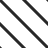
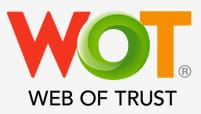

In [85]:
# The requests library makes it easy to call URLs using Python
import requests
import json

notebookIPaddress = None

# The following service responds with an IP address
check_ip_url = "http://checkip.amazonaws.com/"

try:
    notebookIPaddress = requests.get(check_ip_url).text.strip()
except:
    notebookIPaddress = cors_proxy(check_ip_url)

notebookIPaddress

## Geolocating the IP Address

There are several services available that can attempt to return a geographical location, in the form of latitude and longitude co-ordinates, for a given IP address.

Let's start by making sure we have an IP address we can lookup the location for:

In [86]:
if not notebookIPaddress:
    # Use myIPaddress or a dummy address
    if myIPaddress == "your.ip.address.here":
        # Use a valid dummy address
        useIPaddress = "137.108.152.229"
    else:
        useIPaddress = myIPaddress
else:
    # Use notebook IPaddress
    useIPaddress = notebookIPaddress

### Using `geolocation-db.com`

One free service for checking locations of IP addresses is `geolocation-db.com`. *Note that this database may be out-of-date, in part as a conseqence of the way that IP addresses are recycled.*

In [87]:
request_url = "https://geolocation-db.com/json/" + useIPaddress

try:
    response = requests.get(request_url).json()
except:
    response_ = cors_proxy(request_url)
    # Cast the response to a json object
    response = json.loads(response_)

response

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [88]:
import json
import requests

# Specify an IP address or leave empty for local public IP
useIPaddress = "8.8.8.8"
request_url = f"https://geolocation-db.com/json/{useIPaddress}"

headers = {"User-Agent": "Mozilla/5.0"}

try:
    r = requests.get(request_url, headers=headers, timeout=5)
    if r.status_code == 200:
        response = r.json()
    else:
        print(f"HTTP Error {r.status_code}: Falling back to alternative API.")
        response = requests.get(
            f"https://ipapi.co/{useIPaddress}/json/", headers=headers
        ).json()
except Exception as e:
    print(f"Request failed ({e}). Falling back to alternative API...")
    response = requests.get(
        f"https://ipapi.co/{useIPaddress}/json/", headers=headers
    ).json()

response

{'country_code': 'US',
 'country_name': 'United States',
 'city': None,
 'postal': None,
 'latitude': 37.751,
 'longitude': -97.822,
 'IPv4': '8.8.8.8',
 'state': None}

In [89]:
lat = response.get("latitude") or response.get("lat")
lon = response.get("longitude") or response.get("lon")

get_ipython().run_line_magic("folium_map", f"-m {lat},{lon},'IP Geolocation' -z 12")

In [90]:
import json
import requests

# Define the IP address to look up (leave empty string to lookup your own IP)
useIPaddress = "8.8.8.8"  # or ""

request_url = f"https://geolocation-db.com/json/{useIPaddress}"

# Perform request and check HTTP response directly
res = requests.get(request_url)

if res.status_code == 200:
    try:
        response = res.json()
        print(response)
    except json.JSONDecodeError:
        print("Response was not JSON:", res.text)
else:
    print(f"HTTP Error {res.status_code}:", res.text)


{'country_code': 'US', 'country_name': 'United States', 'city': None, 'postal': None, 'latitude': 37.751, 'longitude': -97.822, 'IPv4': '8.8.8.8', 'state': None}


### Using `ipstack.com`

Another free lookup service is [ipstack.com](https://ipstack.com/quickstart).

As before, we need to construct an appropriate URL to call the geolocation service for our specified IP address.

In [91]:
# We can construct a URL based around the IP address
# of the machine making the request as follows:
# Note the bad practice - I shouldn't share my key
# Note also there is no guarantee this key will continue working...
KEY = "d19510a436ddca4cb01822325ca40178"

url = f"http://api.ipstack.com/{useIPaddress}?access_key={KEY}"
url

'http://api.ipstack.com/8.8.8.8?access_key=d19510a436ddca4cb01822325ca40178'

As with the other APIs we have used, the response is provided as a JSON object. You may be getting a feel now for how we might be able to make the request and handle this response.

In [92]:
try:
    r = requests.get(url)
    response_data = r.json()
except:
    response_data = json.loads(cors_proxy(url))

response_data

JSONDecodeError: Expecting value: line 1 column 1 (char 0)

In [93]:
import json
import requests

# 1. Ensure a browser User-Agent is passed to avoid requests getting blocked
headers = {"User-Agent": "Mozilla/5.0"}

# 2. Execute request with explicit error handling
try:
    r = requests.get(url, headers=headers, timeout=5)

    if r.status_code == 200:
        response_data = r.json()
    else:
        print(
            f"Primary request returned HTTP status code {r.status_code}. Attempting fallback..."
        )
        # Fallback to cors_proxy or alternative endpoint
        raw_proxy = cors_proxy(url)
        response_data = json.loads(raw_proxy)

except Exception as err:
    print(f"Request failed: {err}")
    # Secondary safeguard fallback
    try:
        raw_proxy = cors_proxy(url)
        response_data = json.loads(raw_proxy)
    except Exception:
        response_data = {
            "error": "Unable to fetch or parse location data from endpoint."
        }

response_data

Primary request returned HTTP status code 500. Attempting fallback...
Request failed: Expecting value: line 1 column 1 (char 0)


{'error': 'Unable to fetch or parse location data from endpoint.'}

In [94]:
import json
import requests

# 1. Define target IP and your ipstack API key
useIPaddress = "8.8.8.8"  # or your variable name
api_key = "YOUR_IPSTACK_API_KEY"  # Replace with key provided in course materials

# 2. Construct the ipstack HTTP URL (ipstack free tier uses http://)
url = f"http://api.ipstack.com/{useIPaddress}?access_key={api_key}"

# 3. Request and parse response safely
res = requests.get(url)

if res.status_code == 200:
    response_data = res.json()
    # Check if ipstack returned an internal API error object
    if "error" in response_data:
        print("API Key or Query Error:", response_data["error"]["info"])
    else:
        print(response_data)
else:
    print(f"HTTP Error {res.status_code}:", res.text)

HTTP Error 500: 


In [95]:
# Check for 'latitude'/'longitude' (ipstack) or 'lat'/'lon' (ip-api/opencellid)
lat = response_data.get("latitude") or response_data.get("lat")
lon = response_data.get("longitude") or response_data.get("lon")

print(f"Extracted Coordinates: lat={lat}, lon={lon}")

Extracted Coordinates: lat=None, lon=None


In [96]:
if lat is not None and lon is not None:
    get_ipython().run_line_magic("folium_map", f"-m {lat},{lon},'IP Location' -z 12")
else:
    print("Could not retrieve coordinates. Full response from API was:")
    print(response_data)

Could not retrieve coordinates. Full response from API was:
{'error': 'Unable to fetch or parse location data from endpoint.'}


In [97]:
# Extract nested dictionary if present, otherwise default to top-level dictionary
result = response_data.get("result", response_data)

lat = result.get("latitude") or result.get("lat")
lon = result.get("longitude") or result.get("lon")

print(f"Extracted Coordinates: lat={lat}, lon={lon}")

Extracted Coordinates: lat=None, lon=None


In [98]:
if lat is not None and lon is not None:
    get_ipython().run_line_magic(
        "folium_map", f"-m {lat},{lon},'MK7 6AA Location' -z 14"
    )

If you are using a commercial ISP when you look up your IP address via your browser location bar using a service such as http://checkip.amazonaws.com/ - for example, if you are using home broadband through a large ISP - you may find that the location identified is nowhere near you. In this case, the location may refer to the physical network datacentre that is managing your network connection.

If you tried to geocode the IP address in `notebookIPaddress`, the result may surprise you. If the notebook and the python process associated with it is running on a server hosted in the cloud. In some cases, the response may often be empty as the location of the IP address is unknown - the physical location of the IP address may be hard to pin down if the servers they are assigned to are floating in the cloud!

## Optional activities

Using `folium_magic`, or otherwise, plot the various locations returned from your IP address lookups onto a map.

In [99]:
# 1. Gather your retrieved coordinates and labels
# Example using coordinates from your previous outputs:
ip_locations = [
    {"lat": 52.024924, "lon": -0.709727, "label": "Milton Keynes (Postcodes.io)"},
    {"lat": 50.652477, "lon": -1.200002, "label": "Cell Tower Location"},
    # Add any additional IP lookup results here:
    # {"lat": lat_ip2, "lon": lon_ip2, "label": "IP Lookup 2"}
]

# 2. Build the marker parameter string formatted for %folium_map
# Format required: "lat,lon,label"
marker_args = []
for loc in ip_locations:
    marker_args.append(f"-m {loc['lat']},{loc['lon']},'{loc['label']}'")

markers_str = " ".join(marker_args)
print("Generated Marker Parameters:", markers_str)

Generated Marker Parameters: -m 52.024924,-0.709727,'Milton Keynes (Postcodes.io)' -m 50.652477,-1.200002,'Cell Tower Location'


In [100]:
# Centered near the UK average location with zoom level 6
get_ipython().run_line_magic("folium_map", f"{markers_str} -z 6")

In [101]:
import folium

# Create map centered on the first location
center_lat = ip_locations[0]["lat"]
center_lon = ip_locations[0]["lon"]
m = folium.Map(location=[center_lat, center_lon], zoom_start=6)

# Add markers in a loop
for loc in ip_locations:
    folium.Marker(
        location=[loc["lat"], loc["lon"]], popup=loc["label"], tooltip=loc["label"]
    ).add_to(m)

# Render map output
m

<a name="revgeopostcode"></a>
## Activity 6.25 - Reverse geocoding a postcode

*Reverse geocoding* refers to the ability to go *from* a geocoded location, represented as a latitude/longitude pair, for example, back to an address or location.

The *postcodes.io* service supports reverse geocoding by accpeting a latitude/longitude pair and returning the postcode area associated with it, along with a data about other administrative geography regions that the location falls within.

In [102]:
# Use the OU Walton Hall Location
lat, lon = (52.0250, -0.7084)

In [103]:
r = requests.get(f"https://api.postcodes.io/postcodes?lon={lon}&lat={lat}")
response_data = r.json()
response_data

{'status': 200,
 'result': [{'postcode': 'MK7 6AA',
   'quality': 1,
   'eastings': 488625,
   'northings': 237063,
   'country': 'England',
   'nhs_ha': 'South Central',
   'longitude': -0.709727,
   'latitude': 52.024924,
   'european_electoral_region': 'South East',
   'primary_care_trust': 'Milton Keynes',
   'region': 'South East',
   'lsoa': 'Milton Keynes 035D',
   'msoa': 'Milton Keynes 035',
   'incode': '6AA',
   'outcode': 'MK7',
   'parliamentary_constituency': 'Milton Keynes Central',
   'parliamentary_constituency_2024': 'Milton Keynes Central',
   'senedd_constituency': None,
   'senedd_constituency_no': None,
   'admin_district': 'Milton Keynes',
   'parish': 'Walton',
   'admin_county': None,
   'date_of_introduction': '198001',
   'date_of_termination': None,
   'index_of_multiple_deprivation': 20531,
   'admin_ward': 'Monkston',
   'ced': None,
   'ccg': 'NHS Central East',
   'nuts': 'Milton Keynes',
   'pfa': 'Thames Valley',
   'nhs_region': 'East of England',
   

One thing to note from this response is that it actually returns *two* locations. We can write a simple bit of Python code to iterate through the results list and pull out the postcodes.

In [104]:
# Test - can we retrieve the postcode from the first item (list index 0) in the results list?
response_data["result"][0]["postcode"]

'MK7 6AA'

In [105]:
# Iterate through all the results
for result in response_data["result"]:
    print(result["postcode"])

MK7 6AA
MK7 6AE


Finally, let's create a function to display the postcode(s) associated with a supplied latitude, longitude pair.

In [106]:
def get_postcode_from_latlon(lat, lon):
    """Use the postodes.io API to retrieve postcodes for a location"""

    r = requests.get(f"https://api.postcodes.io/postcodes?lon={lon}&lat={lat}")

    # Parse the JSON response
    json = r.json()

    # Extract the results list
    results = json["result"]

    # Create an empty list to hold the postcodes
    postcodes = []

    # Iterate through the results
    for result in results:
        # Extract the postcode
        postcodes.append(result["postcode"])

    return postcodes

In [107]:
get_postcode_from_latlon(lat, lon)

['MK7 6AA', 'MK7 6AE']

## Optional activities

Using the geolocation data (latitude and longitude) co-ordinates returned from the IP address geolocation activities, look-up the postcode for the returned geographical location.

If you are feeling more ambitions, write some simple Python code that will look-up the geolocation of an IP address and return the corresponding postcode for that location.

In [108]:
import requests


def get_postcode_from_coords(lat, lon):
    """
    Takes latitude and longitude coordinates and returns the nearest UK postcode
    using the Postcodes.io reverse geocoding API.
    """
    url = f"https://api.postcodes.io/postcodes?lat={lat}&lon={lon}"

    try:
        response = requests.get(url)
        if response.status_code == 200:
            data = response.json()
            result = data.get("result")
            if result and len(result) > 0:
                # Postcodes.io returns a list of matching nearby postcodes sorted by proximity
                nearest_match = result[0]
                postcode = nearest_match.get("postcode")
                admin_district = nearest_match.get("admin_district")
                return postcode, admin_district
            else:
                return None, "No postcode found near these coordinates."
        else:
            return None, f"HTTP Error {response.status_code}"
    except Exception as e:
        return None, f"Request failed: {e}"


# Test with coordinates from earlier lookup
test_lat = 52.024924
test_lon = -0.709727

postcode, district = get_postcode_from_coords(test_lat, test_lon)
print(f"Coordinates ({test_lat}, {test_lon}) -> Postcode: {postcode} ({district})")

Coordinates (52.024924, -0.709727) -> Postcode: MK7 6AA (Milton Keynes)


In [109]:
import requests


def get_postcode_from_coords(lat, lon):
    """
    Reverse geocodes coordinates to a UK postcode using postcodes.io.
    """
    url = f"https://api.postcodes.io/postcodes?lat={lat}&lon={lon}"
    res = requests.get(url)
    if res.status_code == 200:
        results = res.json().get("result")
        if results:
            return results[0].get("postcode"), results[0].get("admin_district")
    return None, "No UK postcode found for these coordinates."


def ip_to_postcode(ip_address="8.8.8.8"):
    """
    Looks up the geolocation of an IP address via HTTPS and resolves its corresponding postcode.
    """
    # Use HTTPS to prevent redirects or blocked unencrypted requests
    ip_url = f"https://ipapi.co/{ip_address}/json/"

    headers = {"User-Agent": "Mozilla/5.0"}
    response = requests.get(ip_url, headers=headers)

    if response.status_code != 200:
        print(f"IP Geolocation API returned HTTP {response.status_code}")
        return

    data = response.json()
    lat = data.get("latitude")
    lon = data.get("longitude")
    city = data.get("city")
    country = data.get("country_name")

    print(f"IP: {ip_address}")
    print(f"Location: {city}, {country} ({lat}, {lon})")

    # Step 2: Reverse Geocode to UK Postcode
    postcode, district = get_postcode_from_coords(lat, lon)

    if postcode:
        print(f"Nearest Postcode: {postcode} ({district})")
    else:
        print(f"Postcode Lookup: {district}")


# Run pipeline
ip_to_postcode("8.8.8.8")

IP Geolocation API returned HTTP 403


## Summary

In this notebook, you have learned how to geocode several different sorts of location identifer - postcodes, postal addresses and IP addresses.

You have also seen how we can take the JSON data returned from the geolocation services and parse it as python dict that we can then start to work *as data*, for example, by plotting markers associated with identified locations on an interactive map.